# Datasets Exploration

Esplora i CSV prodotti da `scripts/data_summary.py` in `reports/datasets/` — uno per dataset, colonne `subject` + una colonna `present`/`missing` per ogni voce del registro.

## Report csv

In [47]:
from pathlib import Path

import pandas as pd

REPORTS_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets")
CSV_FILES = sorted(REPORTS_DIR.glob("data_summary__*.csv"))
CSV_FILES

[PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets/data_summary__UKLFR_stroke_UKLFR.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets/data_summary__UNIPD_PASPORT.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets/data_summary__UNIPD_PSP.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets/data_summary__UNIPD_WashU.csv')]

Carica ogni CSV in un dict `{nome_dataset: DataFrame}`, usando il nome file (senza prefisso/suffisso) come chiave.

In [48]:
datasets: dict[str, pd.DataFrame] = {}

for path in CSV_FILES:
    name = path.stem.removeprefix("data_summary__")
    datasets[name] = pd.read_csv(path)

list(datasets.keys())


['UKLFR_stroke_UKLFR', 'UNIPD_PASPORT', 'UNIPD_PSP', 'UNIPD_WashU']

### Soggetti totali per dataset

Numero di righe (soggetti) in ciascun CSV.

In [49]:
totals = {name: len(df) for name, df in datasets.items()}

for name, n in totals.items():
    print(f"{name}: {n} soggetti")


UKLFR_stroke_UKLFR: 697 soggetti
UNIPD_PASPORT: 83 soggetti
UNIPD_PSP: 168 soggetti
UNIPD_WashU: 258 soggetti


### Count per colonna

Per ogni dataset, conta quante righe hanno `missing` in ciascuna colonna dati (tutte tranne `subject`), sia in valore assoluto che percentuale sul totale soggetti. Inoltre fa un conteggio generale di quanti soggetti ci sono effettivamente

In [50]:
for name, df in datasets.items():
    data_columns = [c for c in df.columns if c != "subject"]
    n_subjects = len(df)
    
    print(f"=== {name} ({n_subjects} soggetti) ===")
    for col in data_columns:
        # Calcola presenti e mancanti
        n_present = (df[col] == "present").sum()
        
        # Stampa l'output combinato
        print(f"  {col}: {n_present} presenti ")
    print()


=== UKLFR_stroke_UKLFR (697 soggetti) ===
  feature/func/FC-pearson: 0 presenti 
  feature/func/motion: 0 presenti 
  feature/func/outliers: 0 presenti 
  lesion/manual_masks/anat/lesion_mask: 697 presenti 

=== UNIPD_PASPORT (83 soggetti) ===
  feature/func/FC-pearson: 0 presenti 
  feature/func/motion: 0 presenti 
  feature/func/outliers: 0 presenti 
  lesion/manual_masks/anat/lesion_mask: 83 presenti 

=== UNIPD_PSP (168 soggetti) ===
  feature/func/FC-pearson: 0 presenti 
  feature/func/motion: 0 presenti 
  feature/func/outliers: 0 presenti 
  lesion/manual_masks/anat/lesion_mask: 168 presenti 

=== UNIPD_WashU (258 soggetti) ===
  feature/func/FC-pearson: 225 presenti 
  feature/func/motion: 225 presenti 
  feature/func/outliers: 225 presenti 
  lesion/manual_masks/anat/lesion_mask: 202 presenti 



### Mismatch per riga

Per ogni soggetto, confronta i valori di tutte le colonne dati: se coincidono (tutte `present` o tutte `missing`) la riga è coerente, altrimenti è un mismatch (presente in una colonna, mancante in un'altra). Stampa il conteggio e il dettaglio delle righe in mismatch per ciascun dataset.

In [51]:
for name, df in datasets.items():
    data_columns = [c for c in df.columns if c != "subject"]

    is_mismatch = df[data_columns].nunique(axis=1) > 1
    n_mismatch = is_mismatch.sum()

    print(f"=== {name} ===")
    print(f"  coincidenti: {len(df) - n_mismatch} / {len(df)}")
    print(f"  mismatch:    {n_mismatch} / {len(df)}")

    if n_mismatch > 0:
        display(df.loc[is_mismatch, ["subject", *data_columns]])
    print()


=== UKLFR_stroke_UKLFR ===
  coincidenti: 0 / 697
  mismatch:    697 / 697


,subject,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
0,sub-STUKLFR0001,missing,missing,missing,present
1,sub-STUKLFR0002,missing,missing,missing,present
2,sub-STUKLFR0003,missing,missing,missing,present
3,sub-STUKLFR0004,missing,missing,missing,present
4,sub-STUKLFR0006,missing,missing,missing,present
...,...,...,...,...,...
692,sub-STUKLFR0730,missing,missing,missing,present
693,sub-STUKLFR0731,missing,missing,missing,present
694,sub-STUKLFR0732,missing,missing,missing,present
695,sub-STUKLFR0733,missing,missing,missing,present



=== UNIPD_PASPORT ===
  coincidenti: 0 / 83
  mismatch:    83 / 83


,subject,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
0,sub-STUNIPD0489,missing,missing,missing,present
1,sub-STUNIPD0490,missing,missing,missing,present
2,sub-STUNIPD0491,missing,missing,missing,present
3,sub-STUNIPD0492,missing,missing,missing,present
4,sub-STUNIPD0493,missing,missing,missing,present
...,...,...,...,...,...
78,sub-STUNIPD0578,missing,missing,missing,present
79,sub-STUNIPD0580,missing,missing,missing,present
80,sub-STUNIPD0583,missing,missing,missing,present
81,sub-STUNIPD0584,missing,missing,missing,present



=== UNIPD_PSP ===
  coincidenti: 0 / 168
  mismatch:    168 / 168


,subject,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
0,sub-STUNIPD0252,missing,missing,missing,present
1,sub-STUNIPD0253,missing,missing,missing,present
2,sub-STUNIPD0254,missing,missing,missing,present
3,sub-STUNIPD0255,missing,missing,missing,present
4,sub-STUNIPD0256,missing,missing,missing,present
...,...,...,...,...,...
163,sub-STUNIPD0477,missing,missing,missing,present
164,sub-STUNIPD0483,missing,missing,missing,present
165,sub-STUNIPD0485,missing,missing,missing,present
166,sub-STUNIPD0486,missing,missing,missing,present



=== UNIPD_WashU ===
  coincidenti: 169 / 258
  mismatch:    89 / 258


,subject,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
0,sub-STUNIPD0001,missing,missing,missing,present
16,sub-STUNIPD0021,missing,missing,missing,present
20,sub-STUNIPD0026,missing,missing,missing,present
31,sub-STUNIPD0043,missing,missing,missing,present
50,sub-STUNIPD0064,missing,missing,missing,present
...,...,...,...,...,...
253,sub-STUNIPDHC0063,present,present,present,missing
254,sub-STUNIPDHC0064,present,present,present,missing
255,sub-STUNIPDHC0065,present,present,present,missing
256,sub-STUNIPDHC0066,present,present,present,missing


## Merging csv-tsv

In [52]:
import pandas as pd
from pathlib import Path
import os

# Definisci i path principali
REPORTS_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/summaries/datasets")
DERIVATIVES_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives")
OUTPUT_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/metadata")

# Crea la cartella di output se non esiste
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colonne target per il filtraggio
LESION_COL = "lesion/manual_masks/anat/lesion_mask"

# Cerca tutti i CSV di summary
csv_files = sorted(REPORTS_DIR.glob("data_summary__*.csv"))

for csv_path in csv_files:
    # Estrai il nome del dataset (es. UNIPD_WashU)
    dataset_full_name = csv_path.stem.replace("data_summary__", "")
    
    # Ricostruisci il path originale
    if "_" in dataset_full_name:
        center, dataset_name = dataset_full_name.split("_", 1)
        participants_path = DERIVATIVES_DIR / center / dataset_name / "participants.tsv"
    else:
        dataset_name = dataset_full_name
        participants_path = DERIVATIVES_DIR / dataset_name / "participants.tsv"
        
    # Salta se il participants.tsv originale non esiste
    if not participants_path.exists():
        print(f"⚠️ participants.tsv non trovato per {dataset_name}: {participants_path}")
        continue
        
    # 1. Carica il CSV delle disponibilità
    df_summary = pd.read_csv(csv_path)
    
    # 2. Carica il TSV clinico
    df_clinical = pd.read_csv(participants_path, sep='\t')
    
    # 3. Effettua il merge sull'ID
    df_merged = df_clinical.merge(
        df_summary, 
        left_on='participant_id', 
        right_on='subject', 
        how='left'
    )
    
    # Rimuovi la colonna 'subject' che è un duplicato di 'participant_id'
    if 'subject' in df_merged.columns:
        df_merged.drop(columns=['subject'], inplace=True)
        
    print(f"=== Elaborazione {dataset_name} ({len(df_merged)} soggetti) ===")
    
    # 4. Filtra e Salva: MNI Lesions
    if LESION_COL in df_merged.columns:
        df_mni_lesions = df_merged[df_merged[LESION_COL] == 'present'].copy()
        
        out_lesions = OUTPUT_DIR / f"{dataset_name}_participants_mni_lesions.tsv"
        df_mni_lesions.to_csv(out_lesions, sep='\t', index=False)
        print(f"  ✅ Salvati {len(df_mni_lesions)} soggetti con lesioni in {out_lesions.name}")
    else:
        print(f"  ❌ Colonna '{LESION_COL}' non trovata. Impossibile estrarre lesioni.")
        
    # 5. Filtra e Salva: Features Funzionali
    # Cerca in automatico tutte le colonne che iniziano per "feature/"
    feature_cols = [c for c in df_merged.columns if c.startswith("feature/")]
    
    if feature_cols:
        # Teniamo i soggetti che hanno 'present' in ALMENO una colonna feature
        mask_features = (df_merged[feature_cols] == 'present').any(axis=1)
        df_features = df_merged[mask_features].copy()
        
        if len(df_features) > 0:
            out_features = OUTPUT_DIR / f"{dataset_name}_participants_features.tsv"
            df_features.to_csv(out_features, sep='\t', index=False)
            print(f"  ✅ Salvati {len(df_features)} soggetti con feature in {out_features.name}")
        else:
            print(f"  ⚠️ Nessun soggetto con feature funzionali in questo dataset.")
    else:
        print(f"  ⚠️ Nessuna colonna 'feature/' trovata in {dataset_name}.")
    print() # Riga vuota per leggibilità tra un dataset e l'altro


=== Elaborazione stroke_UKLFR (735 soggetti) ===
  ✅ Salvati 697 soggetti con lesioni in stroke_UKLFR_participants_mni_lesions.tsv
  ⚠️ Nessun soggetto con feature funzionali in questo dataset.

=== Elaborazione PASPORT (97 soggetti) ===
  ✅ Salvati 83 soggetti con lesioni in PASPORT_participants_mni_lesions.tsv
  ⚠️ Nessun soggetto con feature funzionali in questo dataset.

=== Elaborazione PSP (237 soggetti) ===
  ✅ Salvati 168 soggetti con lesioni in PSP_participants_mni_lesions.tsv
  ⚠️ Nessun soggetto con feature funzionali in questo dataset.

=== Elaborazione WashU (319 soggetti) ===
  ✅ Salvati 202 soggetti con lesioni in WashU_participants_mni_lesions.tsv
  ✅ Salvati 225 soggetti con feature in WashU_participants_features.tsv



## Report tsv

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### WashU Dataset

Analisi esplorativa dei metadati (`participants.tsv`) per il dataset WashU.

#### Loading

In [60]:
# Caricamento dati (path locale)
#washu_participants_path = "/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives/UNIPD/WashU/participants.tsv"
washu_participants_path = "/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/metadata/WashU_participants_features.tsv"

washu_df = pd.read_csv(washu_participants_path, sep='\t')

#### General Infos

In [61]:
# Dimensioni e prime righe
print(f"Dimensioni dataset WashU: {washu_df.shape}\n")
display(washu_df.head())
# Tipologie di dati per colonna e valori non nulli
washu_df.info()

Dimensioni dataset WashU: (225, 42)



,participant_id,center_id,disease_id,disease_notes,dataset,age,sex,handedness,education,lesion_side,...,ARAT_R,9HPT_L,9HPT_R,Boston_nam,Clock,participant_id_dmp,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
0,sub-STUNIPD0002,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,39.0,M,right,12.0,left,...,57.0,0.33,0.28,13.0,12.0,ST_UNIPD_0002,present,present,present,present
1,sub-STUNIPD0003,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,43.0,F,left,12.0,left,...,0.0,0.43,0.00,4.0,12.0,ST_UNIPD_0003,present,present,present,present
2,sub-STUNIPD0005,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,50.0,M,right,12.0,left,...,57.0,0.21,0.36,9.0,13.0,ST_UNIPD_0005,present,present,present,present
3,sub-STUNIPD0006,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,50.0,F,right,14.0,right,...,57.0,0.22,0.41,14.0,12.0,ST_UNIPD_0006,present,present,present,present
4,sub-STUNIPD0008,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,53.0,M,left,12.0,right,...,57.0,0.33,0.30,12.0,14.0,ST_UNIPD_0008,present,present,present,present


<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        225 non-null    str    
 1   center_id                             225 non-null    str    
 2   disease_id                            225 non-null    str    
 3   disease_notes                         225 non-null    str    
 4   dataset                               225 non-null    str    
 5   age                                   224 non-null    float64
 6   sex                                   225 non-null    str    
 7   handedness                            225 non-null    str    
 8   education                             224 non-null    float64
 9   lesion_side                           142 non-null    str    
 10  clinical_date                         135 non-null    str    
 11  NIHSS                         

#### Global Statistics

In [62]:
print("=== STATISTICHE DESCRITTIVE GLOBALI ===")
# include='all' mostra statistiche anche per le colonne testuali (frequenze, valori unici)
display(washu_df.describe(include='all'))

=== STATISTICHE DESCRITTIVE GLOBALI ===


,participant_id,center_id,disease_id,disease_notes,dataset,age,sex,handedness,education,lesion_side,...,ARAT_R,9HPT_L,9HPT_R,Boston_nam,Clock,participant_id_dmp,feature/func/FC-pearson,feature/func/motion,feature/func/outliers,lesion/manual_masks/anat/lesion_mask
count,225,225,225,225,225,224.000000,225,225,224.000000,142,...,222.000000,137.000000,138.000000,218.000000,137.000000,225,225,225,225,225
unique,225,1,2,2,1,NaN,2,2,NaN,2,...,NaN,NaN,NaN,NaN,NaN,225,1,1,1,2
top,sub-STUNIPD0002,UNIPD,ST,First time ischemic and hemorrhagic strokes,WashU,NaN,M,right,NaN,left,...,NaN,NaN,NaN,NaN,NaN,ST_UNIPD_0002,present,present,present,present
freq,1,225,169,169,225,NaN,125,202,NaN,73,...,NaN,NaN,NaN,NaN,NaN,1,225,225,225,169
mean,NaN,NaN,NaN,NaN,NaN,55.325893,NaN,NaN,13.455357,NaN,...,49.603604,0.279562,0.291812,12.674312,11.576642,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,10.962883,NaN,NaN,2.461865,NaN,...,16.824233,0.144680,0.162154,3.234232,3.982909,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,7.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,12.000000,NaN,...,56.250000,0.240000,0.192500,12.000000,10.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,57.000000,NaN,NaN,13.000000,NaN,...,57.000000,0.310000,0.345000,14.000000,13.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,62.000000,NaN,NaN,15.000000,NaN,...,57.000000,0.380000,0.410000,15.000000,14.000000,NaN,NaN,NaN,NaN,NaN


#### Demograhic Analysis

In [63]:
print("=== COMPOSIZIONE DEL CAMPIONE ===")
display(washu_df['disease_id'].value_counts(dropna=False).to_frame(name='Conteggio'))

print("\n=== DISTRIBUZIONE SESSO ===")
display(pd.crosstab(washu_df['disease_id'], washu_df['sex'], margins=True))

print("\n=== ETÀ MEDIA PER GRUPPO ===")
display(washu_df.groupby('disease_id')['age'].describe()[['count', 'mean', 'std', 'min', 'max']])

=== COMPOSIZIONE DEL CAMPIONE ===


,Conteggio
disease_id,
ST,169
HC,56



=== DISTRIBUZIONE SESSO ===


sex,F,M,All
disease_id,,,
HC,30,26,56
ST,70,99,169
All,100,125,225



=== ETÀ MEDIA PER GRUPPO ===


,count,mean,std,min,max
disease_id,,,,,
HC,56.0,56.464286,12.093521,21.0,83.0
ST,168.0,54.946429,10.570697,19.0,80.0


#### Missing Values

In [64]:
print("=== ANALISI DATI MANCANTI (MISSING VALUES) ===")
# Calcoliamo quanti valori mancano e la percentuale sul totale
missing_counts = washu_df.isnull().sum()
missing_percent = (missing_counts / len(washu_df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentuale (%)': missing_percent
})

# Filtriamo solo le colonne che hanno almeno un missing e ordiniamo in modo decrescente
missing_filtered = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print(f"Trovate {len(missing_filtered)} colonne con dati mancanti:")
display(missing_filtered)


=== ANALISI DATI MANCANTI (MISSING VALUES) ===
Trovate 30 colonne con dati mancanti:


,Missing_Count,Percentuale (%)
GDS_15,199,88.444444
Corsi,160,71.111111
NIHSS,101,44.888889
clinical_date,90,40.000000
behavioral_date,90,40.000000
acq_time,89,39.555556
Clock,88,39.111111
9HPT_L,88,39.111111
9HPT_R,87,38.666667
lesion_side,83,36.888889


#### Visualization

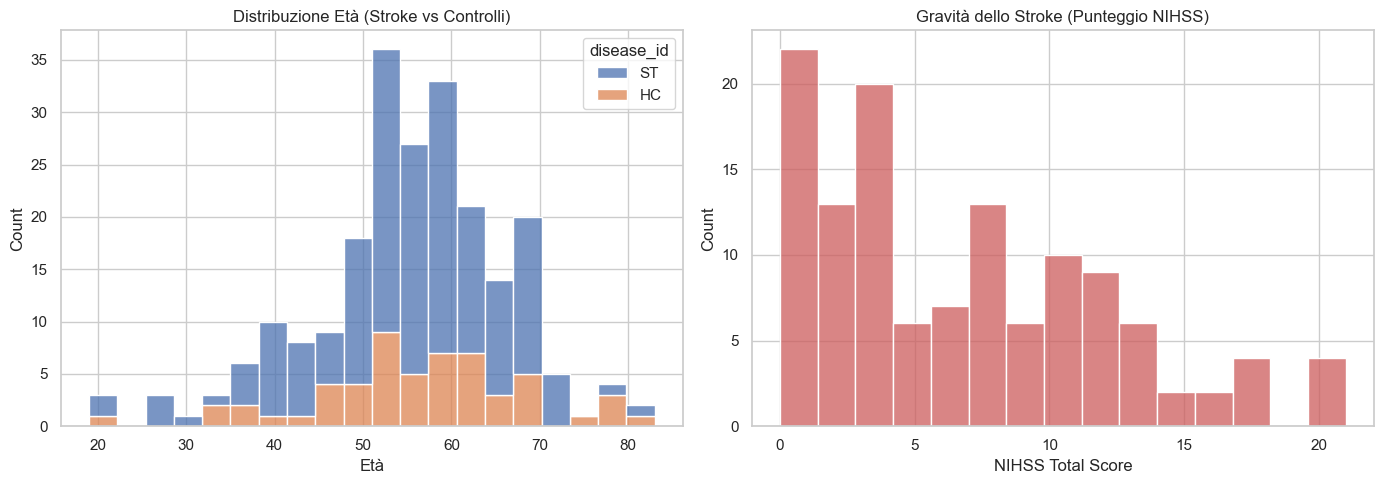

In [65]:
# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribuzione dell'Età tra Pazienti e Controlli
sns.histplot(data=washu_df, x='age', hue='disease_id', multiple='stack', bins=20, ax=axes[0])
axes[0].set_title("Distribuzione Età (Stroke vs Controlli)")
axes[0].set_xlabel("Età")

# Grafico 2: Gravità clinica (NIHSS) - Ovviamente solo per i pazienti
sns.histplot(data=washu_df[washu_df['disease_id'] == 'ST'], x='NIHSS', bins=15, color='indianred', ax=axes[1])
axes[1].set_title("Gravità dello Stroke (Punteggio NIHSS)")
axes[1].set_xlabel("NIHSS Total Score")

plt.tight_layout()
plt.show()
